# Video Background–Foreground Decomposition: Truncated Singular Value Decomposition (Truncated SVD)

This notebook isolates **Truncated SVD** from the original messy pipeline and evaluates it cleanly on:

1. **Simulated data** — a synthetic surveillance video (controlled, known low-rank + sparse structure)
2. **Generalization data** — a real-world video, to test whether the same assumptions hold outside the synthetic benchmark

Truncated SVD is the simplest baseline: it finds the optimal low-rank approximation of the raw observation matrix in the least-squares sense, with no sparsity-promoting mechanism. It is included to show the limits of a naive low-rank approach before comparing against PCA and Robust PCA in the companion notebooks.

**Note on evaluation:** No ground-truth foreground mask is available for either video. All quality
metrics (MSE, PSNR, SSIM, Frobenius error) are therefore computed **against the first frame of the
observation matrix** (`M[:, 0]`) as a static-background reference proxy, not against a true clean
background. This is a self-referential reconstruction-quality check, not a measure of segmentation
accuracy — read the numbers in that light.


## 1. Setup

In [1]:
# ============================================================
# Imports
# ============================================================
import logging
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, NamedTuple, Optional, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity as _ssim_fn
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

if not _SKIMAGE_AVAILABLE:
    log.warning("scikit-image not found — SSIM will be skipped. Install with: pip install scikit-image")


In [9]:
# ============================================================
# Configuration
#
# Fill in the two video paths below before running.
#   simulated_video_path : a synthetic / controlled benchmark video
#                           (e.g. BMC synth scenes) used as the main
#                           experiment.
#   real_video_path       : a real-world video used only to test
#                           generalization of the same pipeline.
#
# No ground truth is required or used anywhere in this notebook.
# ============================================================

@dataclass(frozen=True)
class Config:
    # --- Input videos (EDIT THESE) ---
    simulated_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111.mp4")
    real_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/Video_008.avi")

    # --- Output directory for cached matrices / figures ---
    outputs_dir: Path = Path("./outputs")

    # --- Frame preprocessing ---
    frame_width: int = 120
    frame_height: int = 90

    # --- Time window to extract, in seconds ---
    start_second: float = 25.0
    end_second: float = 30.0
    frame_step: int = 1

    def __post_init__(self):
        self.outputs_dir.mkdir(parents=True, exist_ok=True)


CFG = Config()
log.info(
    "Config loaded: frame size=%dx%d | window=%.1fs-%.1fs",
    CFG.frame_height, CFG.frame_width, CFG.start_second, CFG.end_second,
)


13:52:05 - INFO - Config loaded: frame size=90x120 | window=25.0s-30.0s


## 2. Frame Extraction Utilities

Shared by both the simulated and real-data runs below, so results are directly comparable.

In [3]:
# ============================================================
# Frame extraction utilities
#
# Converts a video file into an observation matrix M of shape
# (n_pixels, n_frames). Each column is one flattened, grayscale,
# [0,1]-normalized frame. Used identically for both the simulated
# and the real video, so results are directly comparable.
# ============================================================

def preprocess_frame(frame_bgr: np.ndarray, h: int, w: int) -> np.ndarray:
    """BGR frame -> normalized grayscale column vector."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (w, h), interpolation=cv2.INTER_AREA)
    return (resized.astype(np.float32).flatten() / 255.0)


def extract_frames(
    video_path: Path,
    cfg: Config,
    cache_name: Optional[str] = None,
) -> np.ndarray:
    """
    Extracts frames from [start_second, end_second] of video_path into
    an observation matrix M, shape (n_pixels, n_frames), float32, [0,1].

    Caches the result to cfg.outputs_dir / cache_name (if given) so
    repeated runs don't re-decode the video.
    """
    if not video_path.exists():
        raise FileNotFoundError(
            f"Video not found: {video_path}\n"
            f"Edit CFG.simulated_video_path / CFG.real_video_path to point "
            f"at a real file before running this cell."
        )

    cache_path = cfg.outputs_dir / cache_name if cache_name else None
    if cache_path is not None and cache_path.exists():
        M = np.load(cache_path)
        log.info("Loaded cached matrix: %s | shape=%s", cache_path.name, M.shape)
        return M

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps else 0.0

    log.info(
        "Video opened: %s | fps=%.2f | total_frames=%d | duration=%.1fs",
        video_path.name, fps, total_frames, duration,
    )

    start_frame = int(cfg.start_second * fps)
    end_frame = int(cfg.end_second * fps)

    if start_frame >= total_frames:
        raise ValueError(
            f"start_second={cfg.start_second}s -> frame {start_frame} "
            f"exceeds video length ({total_frames} frames, {duration:.1f}s)"
        )
    if end_frame > total_frames:
        log.warning("end_second exceeds video length. Clamping to %d frames.", total_frames)
        end_frame = total_frames

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    columns = []
    frame_idx = start_frame
    while frame_idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            log.warning("Stream ended early at frame %d.", frame_idx)
            break
        if (frame_idx - start_frame) % cfg.frame_step == 0:
            columns.append(preprocess_frame(frame, cfg.frame_height, cfg.frame_width))
        frame_idx += 1
    cap.release()

    if not columns:
        raise RuntimeError("No frames extracted. Check start_second/end_second and the video file.")

    M = np.column_stack(columns).astype(np.float32)
    M = np.clip(M, 0.0, 1.0)

    if cache_path is not None:
        np.save(cache_path, M)
        log.info("Matrix cached: %s | shape=%s | %.1f MB", cache_path.name, M.shape, M.nbytes / 1e6)

    log.info("Extracted matrix: shape=%s | dtype=%s", M.shape, M.dtype)
    return M


def inspect_matrix(M: np.ndarray, cfg: Config, title: str = "Observation Matrix") -> None:
    """Logs basic stats and plots sample frames + singular value spectrum."""
    log.info("=" * 50)
    log.info("%s | shape=%s | dtype=%s", title, M.shape, M.dtype)
    log.info("Min/max: %.4f / %.4f | Mean/std: %.4f / %.4f", M.min(), M.max(), M.mean(), M.std())

    k = min(1000, M.shape[1])
    _, s, _ = np.linalg.svd(M[:, :k], full_matrices=False)
    explained = np.cumsum(s ** 2) / np.sum(s ** 2)
    rank_90 = int(np.searchsorted(explained, 0.90)) + 1
    rank_99 = int(np.searchsorted(explained, 0.99)) + 1
    log.info("Estimated rank (90%% variance): %d | (99%% variance): %d", rank_90, rank_99)
    log.info("=" * 50)

    n_show = min(5, M.shape[1])
    indices = np.linspace(0, M.shape[1] - 1, n_show, dtype=int)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f"{title}: Sample Frames", fontsize=12)
    for ax, idx in zip(axes, indices):
        frame = M[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Frame {idx}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(s[:10], "o-", color="steelblue", markersize=4)
    axes[0].set_title("Top 10 Singular Values")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Singular value")
    axes[0].grid(alpha=0.3)

    axes[1].plot(explained[:30], "s-", color="darkorange", markersize=4)
    axes[1].axhline(0.90, color="red", linestyle="--", label="90%")
    axes[1].axhline(0.99, color="gray", linestyle="--", label="99%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative variance ratio")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Method: Truncated SVD (Eckart–Young baseline)

Truncated SVD finds the best rank-$k$ approximation of $M$ in the least-squares sense:

$$
\min_{L} \; \|M - L\|_F \quad \text{s.t.} \quad \operatorname{rank}(L) \le k
$$

By the **Eckart–Young theorem**, the closed-form solution is built directly from the SVD of $M = U\Sigma V^T$:

$$
L = U_k \Sigma_k V_k^T, \qquad S = M - L
$$

- $L$ (rank-$k$) is treated as the **background** estimate.
- $S$ (the residual) is treated as the **foreground** estimate.

This is *not* a robust decomposition — it minimizes overall reconstruction error but has no mechanism
to push $S$ towards sparsity. Moving objects often "leak" into $L$ as ghosting, and $S$ picks up
background noise as well as real foreground. It is included here as the simplest possible baseline.


In [4]:
# ============================================================
# Truncated SVD baseline
#
#   min_L ||M - L||_F   s.t. rank(L) <= k
#   Closed-form solution: L = U_k @ Sigma_k @ Vt_k   (Eckart-Young)
#   S = M - L
# ============================================================

class SVDResult(NamedTuple):
    L: np.ndarray
    S: np.ndarray
    singular_values: np.ndarray
    rank_used: int
    runtime_sec: float


def truncated_svd(M: np.ndarray, k: int) -> SVDResult:
    """Decomposes M into a rank-k background L and residual S via truncated SVD."""
    assert M.ndim == 2, "M must be a 2D matrix"
    assert 1 <= k <= min(M.shape), f"k={k} out of valid range [1, {min(M.shape)}]"

    t0 = time.perf_counter()
    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    U_k, s_k, Vt_k = U[:, :k], s[:k], Vt[:k, :]
    L = (U_k * s_k) @ Vt_k
    S = M - L

    L = np.clip(L, 0.0, 1.0).astype(np.float32)
    S = np.clip(S, 0.0, 1.0).astype(np.float32)
    runtime = time.perf_counter() - t0

    frob = np.linalg.norm(M - L, "fro") / np.linalg.norm(M, "fro")
    log.info("Truncated SVD | rank=%d | Frobenius error=%.4f | time=%.2fs", k, frob, runtime)

    return SVDResult(L=L, S=S, singular_values=s, rank_used=k, runtime_sec=runtime)


In [5]:
# ============================================================
# Visualization: Original / Background / Foreground grid
# ============================================================

def visualize_svd_result(result: SVDResult, M: np.ndarray, cfg: Config, frame_indices: Optional[List[int]] = None) -> None:
    if frame_indices is None:
        n = M.shape[1]
        frame_indices = sorted(set([0, n // 4, n // 2, 3 * n // 4]))

    n_show = len(frame_indices)
    fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 8))
    if n_show == 1:
        axes = axes.reshape(3, 1)
    fig.suptitle(f"Truncated SVD (rank={result.rank_used})", fontsize=13, fontweight="bold")

    row_labels = ["Original M", "Background L (SVD)", "Foreground S (SVD)"]
    sources = [M, result.L, result.S]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight="bold")
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    plt.tight_layout()
    plt.show()


def run_svd_rank_sweep(M: np.ndarray, cfg: Config, ranks: List[int] = (1, 3, 5)) -> dict:
    """Runs truncated SVD at several ranks and visualizes each, to show the
    background-vs-ghosting trade-off as k increases."""
    results = {}
    log.info("Running SVD rank sweep: %s", list(ranks))
    for k in ranks:
        results[k] = truncated_svd(M, k)

    log.info("-" * 55)
    log.info("%-8s %-20s %-15s", "rank k", "Frobenius error", "runtime (s)")
    log.info("-" * 55)
    for k, r in results.items():
        frob = np.linalg.norm(M - r.L, "fro") / np.linalg.norm(M, "fro")
        log.info("%-8d %-20.4f %-15.3f", k, frob, r.runtime_sec)

    for k, r in results.items():
        visualize_svd_result(r, M, cfg)

    return results


## 3. Metrics (no ground truth)

Frobenius error, MSE, PSNR, and SSIM — all computed against Frame 0 of the observation matrix as a static-background reference proxy.

In [6]:
# ============================================================
# Metrics  (no ground truth available)
#
# All metrics compare the reconstructed background L against a
# single reference column: Frame 0 of the observation matrix M.
# This is a proxy for a "clean background" frame, NOT a true
# ground truth. Interpret accordingly:
#
#   - Frobenius error : ||M - L||_F / ||M||_F  (overall reconstruction)
#   - MSE / PSNR / SSIM : per-frame quality of L vs. reference frame,
#     averaged over all frames.
# ============================================================

from typing import NamedTuple


class MetricsResult(NamedTuple):
    frobenius_error: float
    mse: float
    psnr_db: float
    ssim: Optional[float]


def frobenius_error(M: np.ndarray, L: np.ndarray) -> float:
    """Relative Frobenius reconstruction error: ||M - L||_F / ||M||_F."""
    assert M.shape == L.shape, f"Shape mismatch: M={M.shape}, L={L.shape}"
    norm_M = np.linalg.norm(M, "fro")
    if norm_M == 0:
        raise ValueError("M is the zero matrix - Frobenius error undefined.")
    return float(np.linalg.norm(M - L, "fro") / norm_M)


def mse_frame(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Mean squared error between two equally-shaped arrays."""
    assert reference.shape == estimate.shape
    return float(np.mean((reference.astype(np.float64) - estimate.astype(np.float64)) ** 2))


def mse_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean MSE across all columns of L vs. a single reference column."""
    values = [mse_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    return float(np.mean(values))


def psnr_frame(reference: np.ndarray, estimate: np.ndarray, max_val: float = 1.0) -> float:
    """PSNR (dB) between two equally-shaped arrays."""
    mse = mse_frame(reference, estimate)
    if mse == 0.0:
        return float("inf")
    return float(10.0 * np.log10(max_val ** 2 / mse))


def psnr_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean PSNR across all columns of L vs. a single reference column."""
    values = [psnr_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    finite = [v for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else float("inf")


def ssim_frame(reference: np.ndarray, estimate: np.ndarray, cfg: Config) -> Optional[float]:
    """SSIM between two flattened frames, reshaped to (H, W). None if skimage missing."""
    if not _SKIMAGE_AVAILABLE:
        return None
    ref_2d = reference.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    est_2d = estimate.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    return float(_ssim_fn(ref_2d, est_2d, data_range=1.0))


def ssim_matrix(reference_col: np.ndarray, L: np.ndarray, cfg: Config) -> Optional[float]:
    """Mean SSIM across all columns of L vs. a single reference column."""
    if not _SKIMAGE_AVAILABLE:
        return None
    values = [ssim_frame(reference_col, L[:, j], cfg) for j in range(L.shape[1])]
    return float(np.mean(values))


def compute_metrics(M: np.ndarray, L: np.ndarray, cfg: Config, label: str = "") -> MetricsResult:
    """Computes Frobenius error, MSE, PSNR and SSIM of L vs. Frame 0 of M."""
    reference_col = M[:, 0]

    frob = frobenius_error(M, L)
    mse_val = mse_matrix(reference_col, L)
    psnr_val = psnr_matrix(reference_col, L)
    ssim_val = ssim_matrix(reference_col, L, cfg)

    log.info("-" * 55)
    log.info("Metrics%s", f" [{label}]" if label else "")
    log.info("  Frobenius error : %.6f", frob)
    log.info("  MSE             : %.6f", mse_val)
    log.info("  PSNR            : %.2f dB", psnr_val)
    log.info("  SSIM            : %s", f"{ssim_val:.4f}" if ssim_val is not None else "N/A (scikit-image missing)")
    log.info("-" * 55)

    return MetricsResult(frobenius_error=frob, mse=mse_val, psnr_db=psnr_val, ssim=ssim_val)


In [7]:
# ============================================================
# Plot: Simulated vs. Generalization metrics, side by side
#
# PSNR lives on a much larger numeric scale (dB) than Frobenius
# error / MSE / SSIM ([0,1]-ish), so it gets its own panel —
# otherwise it visually flattens the other bars to nothing.
# ============================================================

def plot_metrics_comparison(sim_metrics: MetricsResult, real_metrics: MetricsResult, cfg: Config) -> None:
    """
    Bar charts comparing Truncated SVD metrics between the simulated run
    and the real-data (generalization) run. PSNR is split into its own
    subplot since its scale dwarfs the other metrics.
    """
    small_entries = [
        ("Frobenius\nerror", sim_metrics.frobenius_error, real_metrics.frobenius_error, False),
        ("MSE", sim_metrics.mse, real_metrics.mse, False),
    ]
    if sim_metrics.ssim is not None and real_metrics.ssim is not None:
        small_entries.append(("SSIM", sim_metrics.ssim, real_metrics.ssim, True))

    psnr_entry = ("PSNR (dB)", sim_metrics.psnr_db, real_metrics.psnr_db, True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [len(small_entries), 1]})

    def _draw(ax, entries, title):
        labels = [e[0] for e in entries]
        sim_vals = [e[1] for e in entries]
        real_vals = [e[2] for e in entries]
        higher_wins = [e[3] for e in entries]

        x = np.arange(len(entries))
        width = 0.35
        bars_sim = ax.bar(x - width / 2, sim_vals, width, label="Simulated", color="steelblue", alpha=0.85)
        bars_real = ax.bar(x + width / 2, real_vals, width, label="Real (generalization)", color="darkorange", alpha=0.85)

        for bar in list(bars_sim) + list(bars_real):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

        tick_labels = [f"{lbl}\n{'↑ higher better' if hw else '↓ lower better'}" for lbl, hw in zip(labels, higher_wins)]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    _draw(axes[0], small_entries, "Reconstruction / Similarity Metrics")
    _draw(axes[1], [psnr_entry], "PSNR (separate scale)")
    axes[0].set_ylabel("Metric value")
    axes[0].legend(fontsize=9)

    fig.suptitle("Truncated SVD: Simulated vs. Generalization Metrics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 4. Run on Simulated Data

13:52:13 - INFO - Video opened: 111.mp4 | fps=25.00 | total_frames=1499 | duration=60.0s
13:52:13 - INFO - Matrix cached: M_simulated.npy | shape=(10800, 125) | 5.4 MB
13:52:13 - INFO - Extracted matrix: shape=(10800, 125) | dtype=float32
13:52:13 - INFO - ==================================================
13:52:13 - INFO - Simulated Data — Observation Matrix M | shape=(10800, 125) | dtype=float32
13:52:13 - INFO - Min/max: 0.0824 / 0.9647 | Mean/std: 0.3760 / 0.1230
13:52:13 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
13:52:13 - INFO - ==================================================


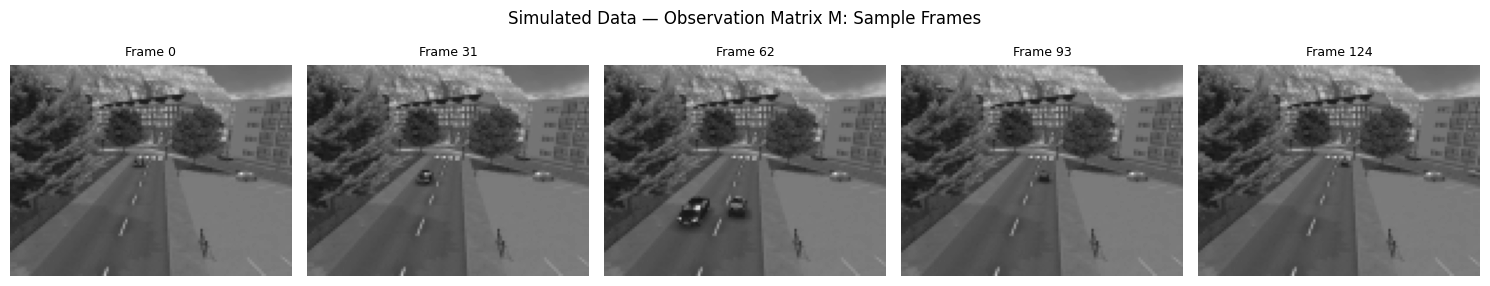

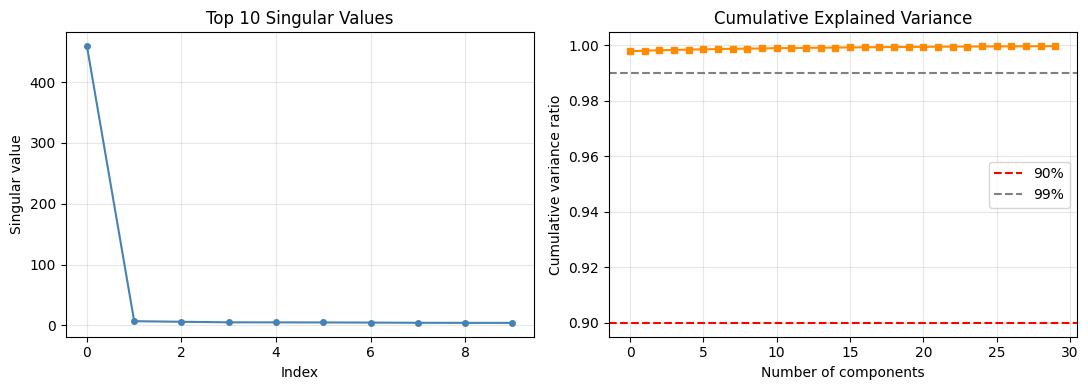

In [10]:
M_sim = extract_frames(CFG.simulated_video_path, CFG, cache_name="M_simulated.npy")
inspect_matrix(M_sim, CFG, title="Simulated Data — Observation Matrix M")


13:52:13 - INFO - Running SVD rank sweep: [1, 3, 5]
13:52:13 - INFO - Truncated SVD | rank=1 | Frobenius error=0.0470 | time=0.12s
13:52:14 - INFO - Truncated SVD | rank=3 | Frobenius error=0.0428 | time=0.07s
13:52:14 - INFO - Truncated SVD | rank=5 | Frobenius error=0.0400 | time=0.07s
13:52:14 - INFO - -------------------------------------------------------
13:52:14 - INFO - rank k   Frobenius error      runtime (s)    
13:52:14 - INFO - -------------------------------------------------------
13:52:14 - INFO - 1        0.0470               0.118          
13:52:14 - INFO - 3        0.0428               0.074          
13:52:14 - INFO - 5        0.0400               0.067          


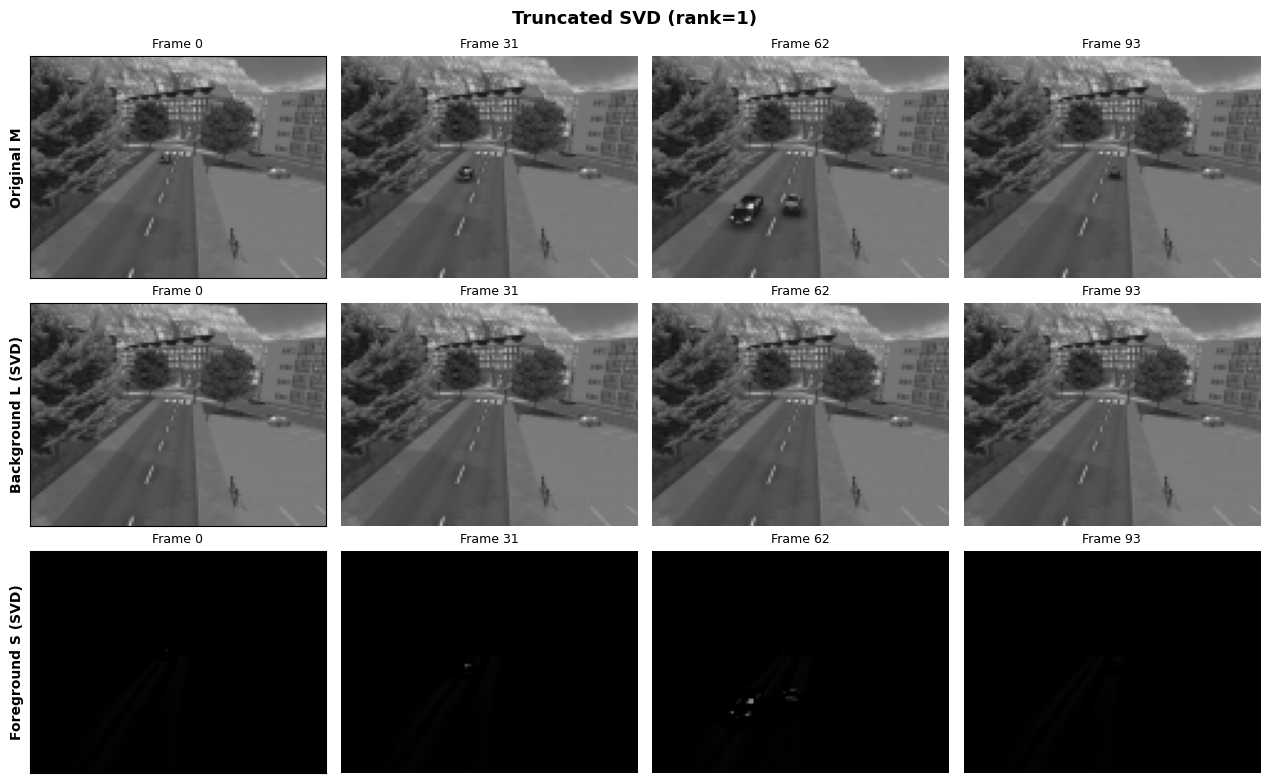

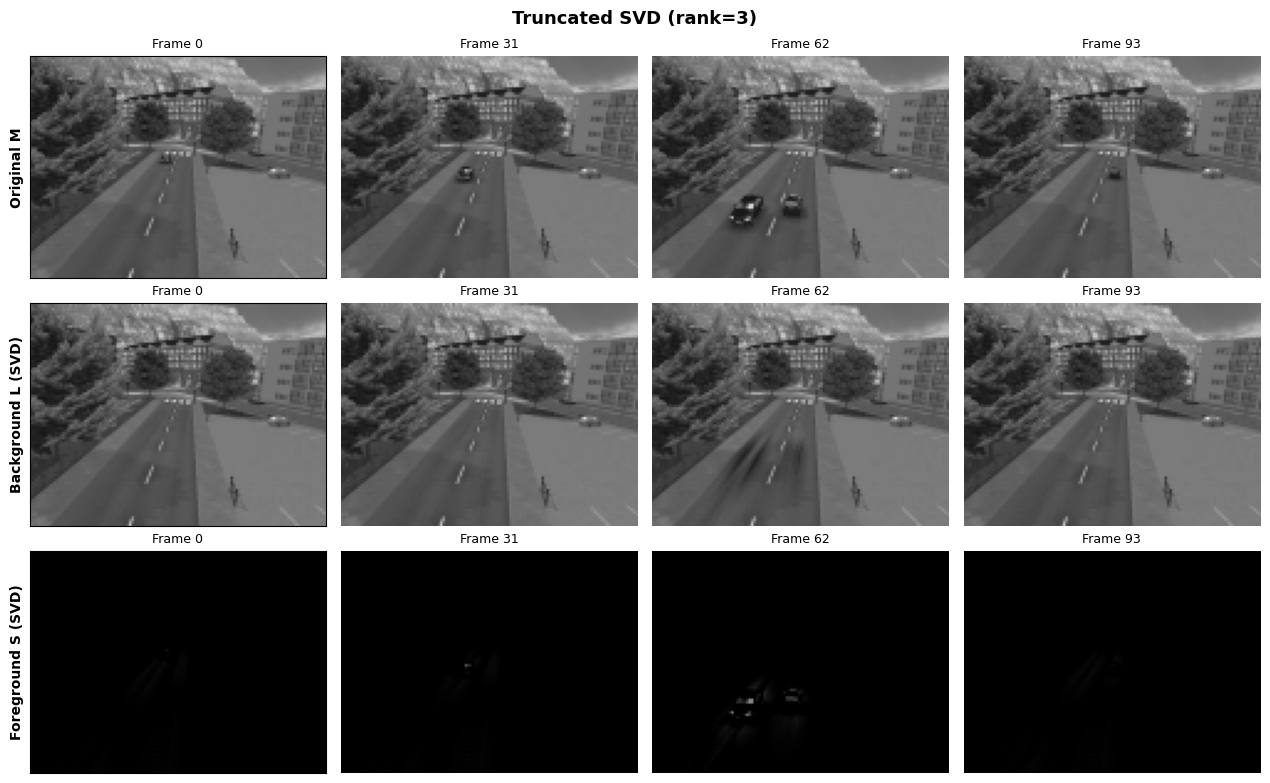

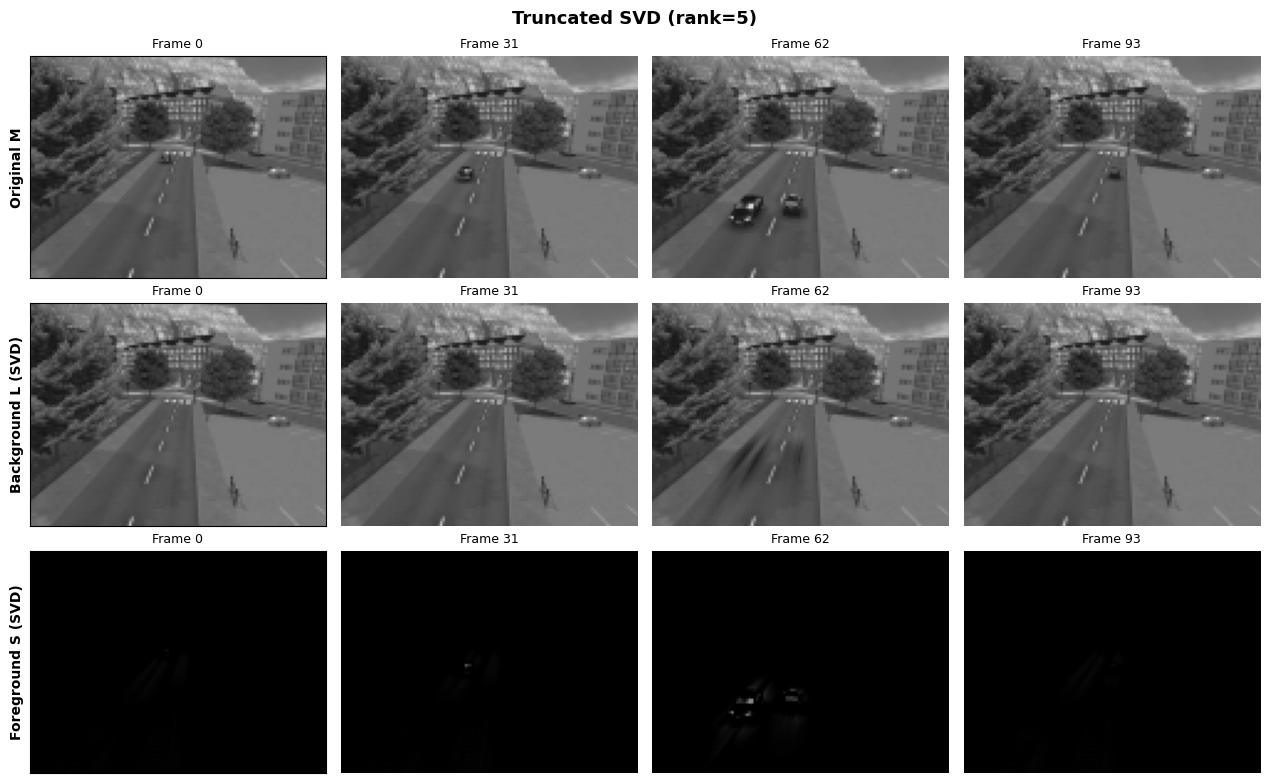

In [11]:
# Rank sweep to illustrate the background/ghosting trade-off (k=1, 3, 5)
svd_sweep_sim = run_svd_rank_sweep(M_sim, CFG, ranks=[1, 3, 5])

# Selected rank used for the head-to-head comparison below.
# k=3 balances background cleanliness against ghosting -- adjust if your
# video has different motion characteristics.
SVD_RANK = 3
svd_sim = svd_sweep_sim[SVD_RANK]


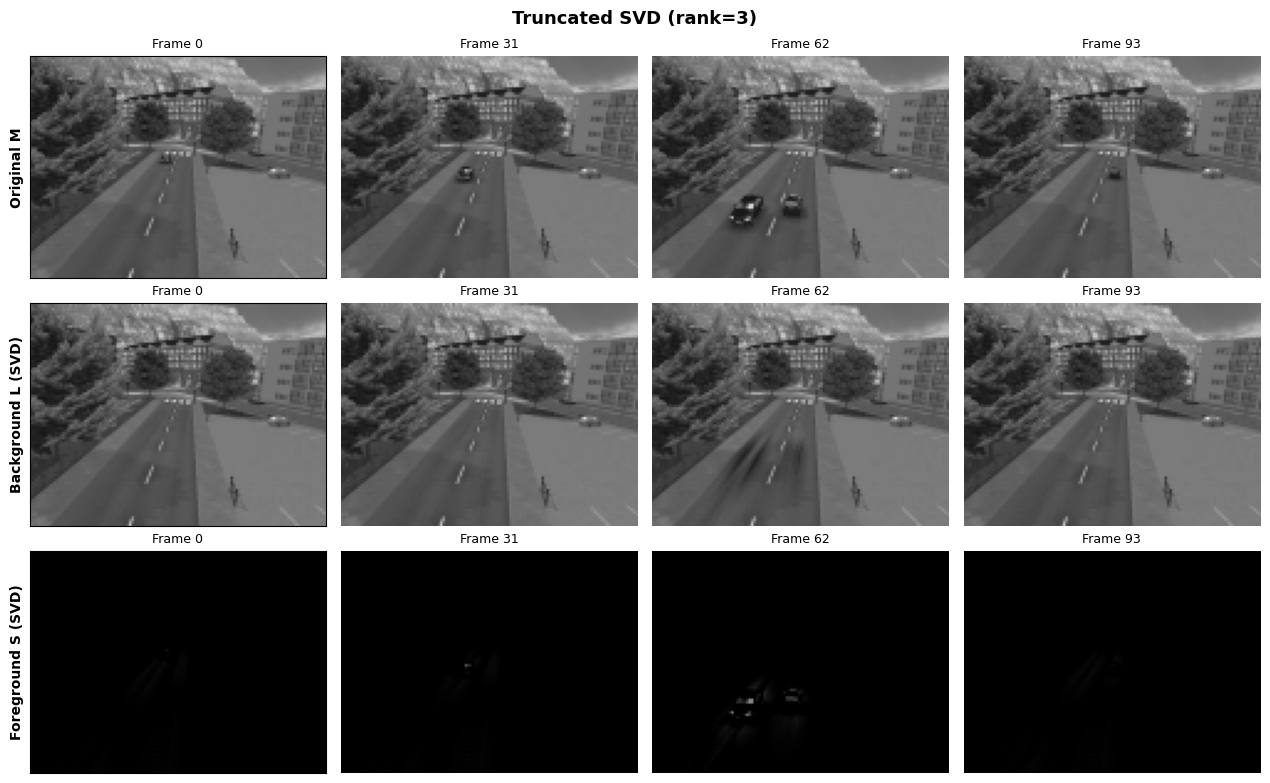

13:52:17 - INFO - -------------------------------------------------------
13:52:17 - INFO - Metrics [SVD - Simulated]
13:52:17 - INFO -   Frobenius error : 0.042754
13:52:17 - INFO -   MSE             : 0.000099
13:52:17 - INFO -   PSNR            : 42.26 dB
13:52:17 - INFO -   SSIM            : 0.9870
13:52:17 - INFO - -------------------------------------------------------


In [12]:
visualize_svd_result(svd_sim, M_sim, CFG)
svd_metrics_sim = compute_metrics(M_sim, svd_sim.L, CFG, label="SVD - Simulated")


## 5. Generalization: Run on Real Data

Same preprocessing, same rank, same metrics — applied to a real-world video to test whether the low-rank assumption still holds outside the synthetic benchmark.

13:52:17 - INFO - Video opened: Video_008.avi | fps=10.00 | total_frames=793 | duration=79.3s
13:52:17 - INFO - Matrix cached: M_real.npy | shape=(10800, 50) | 2.2 MB
13:52:17 - INFO - Extracted matrix: shape=(10800, 50) | dtype=float32
13:52:17 - INFO - ==================================================
13:52:17 - INFO - Real Data — Observation Matrix M | shape=(10800, 50) | dtype=float32
13:52:17 - INFO - Min/max: 0.0784 / 0.9922 | Mean/std: 0.4620 / 0.1674
13:52:17 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
13:52:17 - INFO - ==================================================


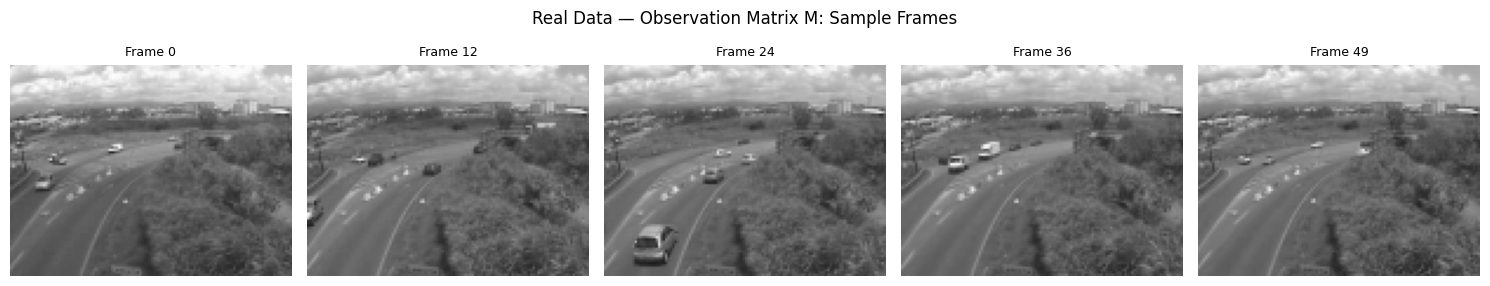

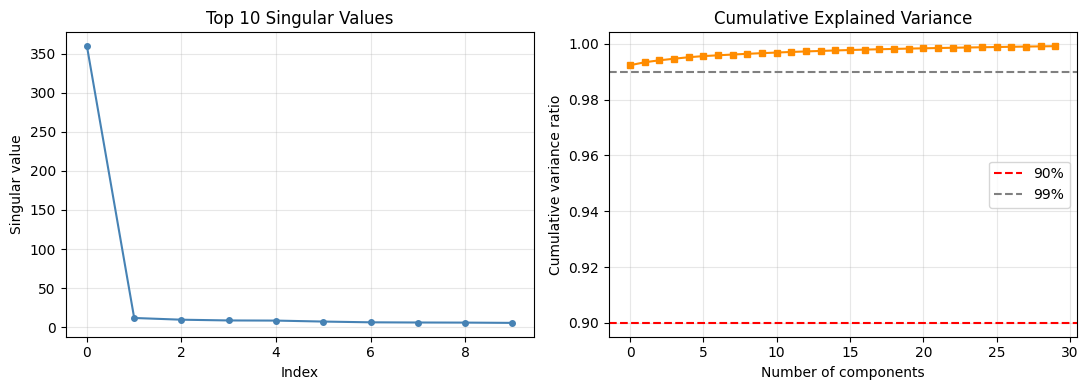

In [13]:
M_real = extract_frames(CFG.real_video_path, CFG, cache_name="M_real.npy")
inspect_matrix(M_real, CFG, title="Real Data — Observation Matrix M")


13:52:17 - INFO - Truncated SVD | rank=3 | Frobenius error=0.0770 | time=0.02s


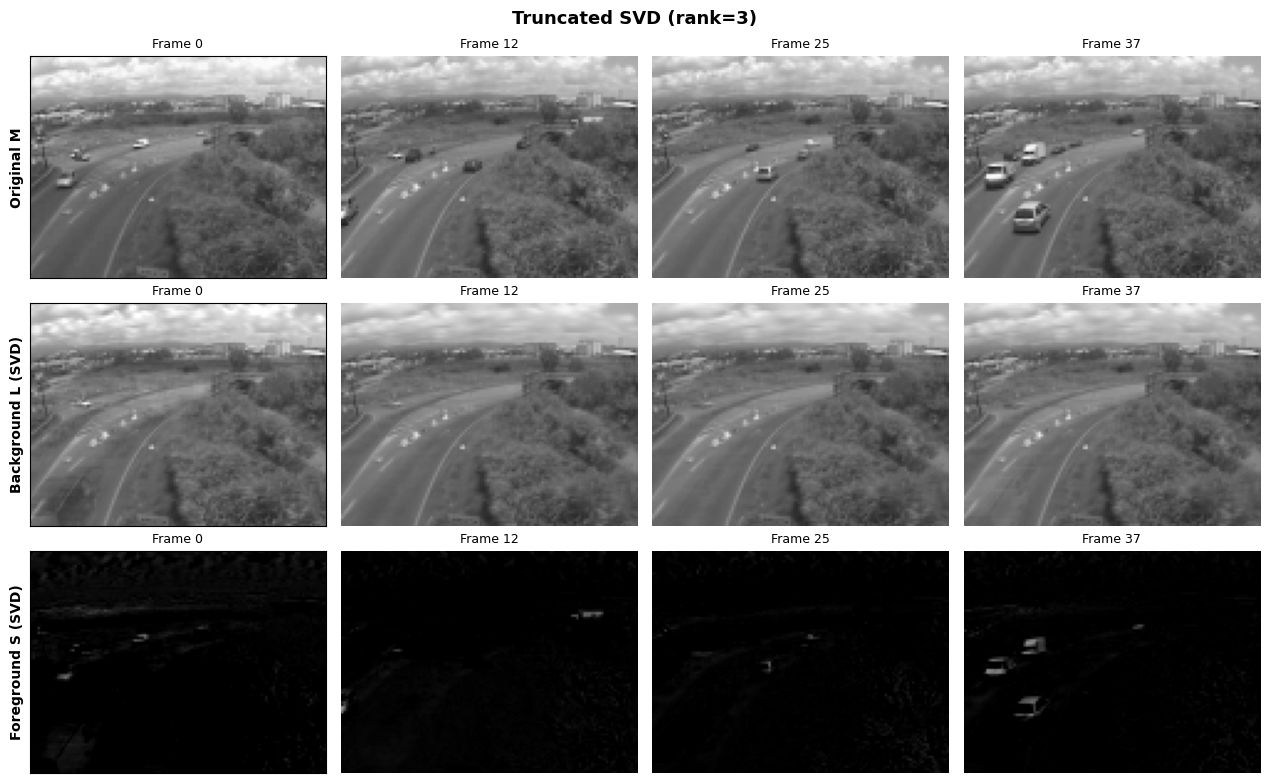

13:52:18 - INFO - -------------------------------------------------------
13:52:18 - INFO - Metrics [SVD - Real (generalization)]
13:52:18 - INFO -   Frobenius error : 0.077012
13:52:18 - INFO -   MSE             : 0.004426
13:52:18 - INFO -   PSNR            : 23.76 dB
13:52:18 - INFO -   SSIM            : 0.8362
13:52:18 - INFO - -------------------------------------------------------


In [14]:
svd_real = truncated_svd(M_real, SVD_RANK)
visualize_svd_result(svd_real, M_real, CFG)
svd_metrics_real = compute_metrics(M_real, svd_real.L, CFG, label="SVD - Real (generalization)")


## 6. Simulated vs. Generalization: Metrics Comparison

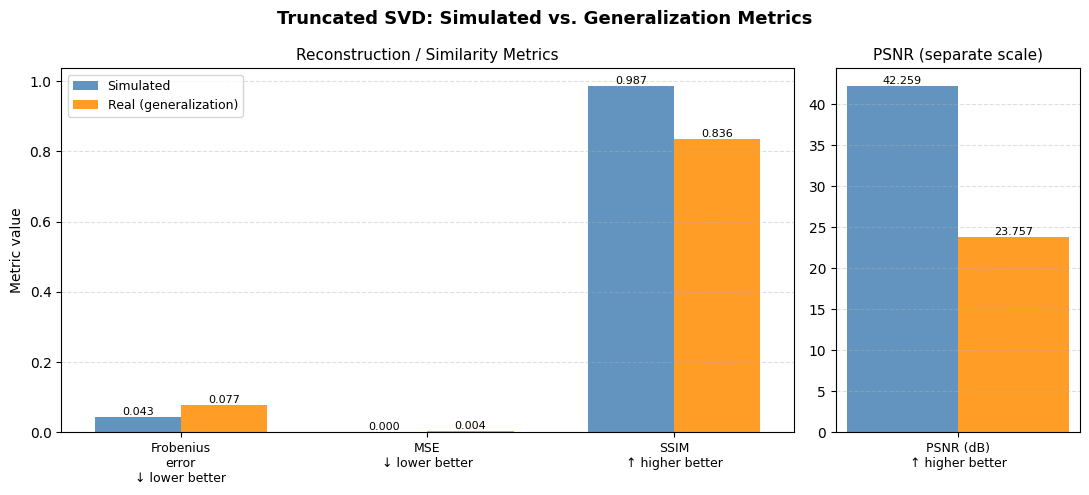

Metric                 Simulated   Real (generalization)
--------------------------------------------------------
Frobenius error           0.0428                  0.0770
MSE                     0.000099                0.004426
PSNR (dB)                  42.26                   23.76
SSIM                      0.9870                  0.8362


In [15]:
plot_metrics_comparison(svd_metrics_sim, svd_metrics_real, CFG)

print(f"{'Metric':<18}{'Simulated':>14}{'Real (generalization)':>24}")
print("-" * 56)
print(f"{'Frobenius error':<18}{svd_metrics_sim.frobenius_error:>14.4f}{svd_metrics_real.frobenius_error:>24.4f}")
print(f"{'MSE':<18}{svd_metrics_sim.mse:>14.6f}{svd_metrics_real.mse:>24.6f}")
print(f"{'PSNR (dB)':<18}{svd_metrics_sim.psnr_db:>14.2f}{svd_metrics_real.psnr_db:>24.2f}")
ssim_sim_str = f"{svd_metrics_sim.ssim:.4f}" if svd_metrics_sim.ssim is not None else "N/A"
ssim_real_str = f"{svd_metrics_real.ssim:.4f}" if svd_metrics_real.ssim is not None else "N/A"
print(f"{'SSIM':<18}{ssim_sim_str:>14}{ssim_real_str:>24}")


## 7. Takeaways

- **Reconstruction error (Frobenius/MSE/PSNR) is the metric SVD is built to optimize** — by the
  Eckart–Young theorem, no other rank-$k$ matrix can beat it on these. Low Frobenius error here is
  expected, not impressive.
- A drop in PSNR/SSIM and a rise in MSE/Frobenius error from simulated → real data indicates the
  real video's background is less stationary (lighting changes, camera shake, more motion) than the
  synthetic scene — i.e. the low-rank assumption holds less well.
- Watch the **foreground (S) panels** in the visualizations above, not just the numbers: SVD
  typically leaves visible ghosting of moving objects in the background L, since nothing in the
  objective penalizes that. This motivates the PCA and Robust PCA notebooks.
